<a href="https://colab.research.google.com/github/KandyalaYaswanthSai/21691a31j5-/blob/main/Pneumonia_Detection_and_Severity_Classification_Code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
import cv2

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#Dataset Loading from ZIP File
import zipfile
import os
# Path to the uploaded zip file
zip_ref = zipfile.ZipFile('/content/drive/MyDrive/chest_xray.zip', 'r')
zip_ref.extractall('/content')
zip_ref.close()
print("Dataset extracted successfully!")


Dataset extracted successfully!


In [ ]:
# Enhanced Data Augmentation for Training Data
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.3,
    brightness_range=[0.8,1.2],
    horizontal_flip=True,
    fill_mode='nearest'
)

In [ ]:
# Training Data Generator
train_images = "/content/chest_xray/train"
train_generator = train_datagen.flow_from_directory(
    train_images,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    color_mode="grayscale"
)

test_datagen = ImageDataGenerator(rescale=1./255)

# Test Data Generator
test_images = "/content/chest_xray/test"
test_generator = test_datagen.flow_from_directory(
    test_images,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    color_mode="grayscale"
)

# Validation Data Generator
validation_images = "/content/chest_xray/val"
validation_generator = test_datagen.flow_from_directory(
    validation_images,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    color_mode="grayscale"
)

Found 5216 images belonging to 2 classes.
Found 624 images belonging to 2 classes.
Found 622 images belonging to 2 classes.


In [ ]:
train_generator.class_indices


{'NORMAL': 0, 'PNEUMONIA': 1}

In [ ]:
# ConvXNet Model Definition
def ConvXNet(input_shape=(224, 224, 1)):
    inputs = tf.keras.layers.Input(shape=input_shape)

    # ConvXNet Block 1
    x = tf.keras.layers.Conv2D(32, (3,3), activation='relu', padding='same')(inputs)
    x = tf.keras.layers.Conv2D(32, (3,3), activation='relu', padding='same')(x)
    x = tf.keras.layers.MaxPool2D(2,2)(x)

    # ConvXNet Block 2
    x = tf.keras.layers.Conv2D(64, (3,3), activation='relu', padding='same')(x)
    x = tf.keras.layers.Conv2D(64, (3,3), activation='relu', padding='same')(x)
    x = tf.keras.layers.MaxPool2D(2,2)(x)

    # ConvXNet Block 3
    x = tf.keras.layers.Conv2D(128, (3,3), activation='relu', padding='same')(x)
    x = tf.keras.layers.Conv2D(128, (3,3), activation='relu', padding='same')(x)
    x = tf.keras.layers.MaxPool2D(2,2)(x)

    # ConvXNet Block 4
    x = tf.keras.layers.Conv2D(256, (3,3), activation='relu', padding='same')(x)
    x = tf.keras.layers.Conv2D(256, (3,3), activation='relu', padding='same')(x)
    x = tf.keras.layers.MaxPool2D(2,2)(x)

    # Fully Connected Layers
    x = tf.keras.layers.Flatten()(x)
    x = tf.keras.layers.Dense(512, activation='relu')(x)
    x = tf.keras.layers.Dropout(0.5)(x)
    x = tf.keras.layers.Dense(256, activation='relu')(x)
    x = tf.keras.layers.Dense(1, activation='sigmoid')(x)

    model = tf.keras.models.Model(inputs, x)
    return model


In [ ]:
model = ConvXNet()

In [ ]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 224, 224, 1)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 224, 224, 32)        │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 224, 224, 32)        │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 112, 112, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 112, 112, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 112, 112, 64)        │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 56, 56, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 56, 56, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 56, 56, 128)         │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 28, 28, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_6 (Conv2D)                    │ (None, 28, 28, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_7 (Conv2D)                    │ (None, 28, 28, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 14, 14, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 50176)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 512)                 │      25,690,624 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 256)                 │         131,328 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │             257 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 26,993,889 (102.97 MB)

 Trainable params: 26,993,889 (102.97 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [ ]:
history = model.fit(train_generator, epochs=50,validation_data=validation_generator)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 100s 495ms/step - accuracy: 0.7335 - loss: 0.5866 - val_accuracy: 0.7901 - val_loss: 0.4341
Epoch 2/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 70s 431ms/step - accuracy: 0.8322 - loss: 0.3784 - val_accuracy: 0.8317 - val_loss: 0.3862
Epoch 3/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 70s 427ms/step - accuracy: 0.8562 - loss: 0.3196 - val_accuracy: 0.8125 - val_loss: 0.4116
Epoch 4/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 71s 438ms/step - accuracy: 0.8695 - loss: 0.2943 - val_accuracy: 0.7933 - val_loss: 0.4200
Epoch 5/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 69s 424ms/step - accuracy: 0.8636 - loss: 0.3085 - val_accuracy: 0.7965 - val_loss: 0.4312
Epoch 6/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 83s 429ms/step - accuracy: 0.8729 - loss: 0.2865 - val_accuracy: 0.7901 - val_loss: 0.4450
Epoch 7/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 67s 408ms/step - accuracy: 0.8734 - loss: 0.2787 - val_accuracy: 0.7628 - val_loss: 0.4940
Epoch 8/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 72s 439ms/step - accuracy: 0.8755 - loss: 

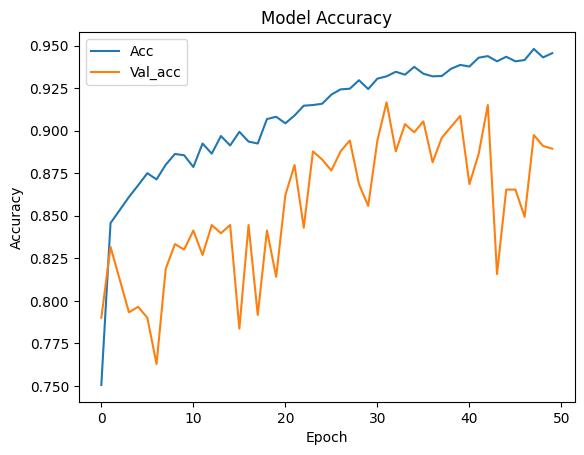

In [ ]:
#Visulaize the accuracy in each epoch
plt.plot(history.history['accuracy'],label='Acc')
plt.plot(history.history['val_accuracy'],label='Val_acc')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

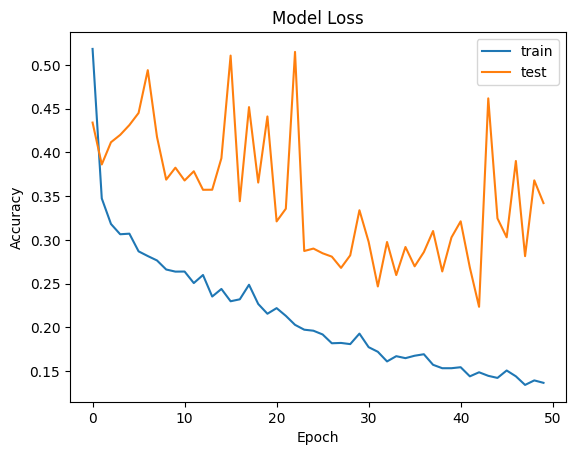

In [ ]:
#Visulaize the Loss in each epoch
import matplotlib.pyplot as plt
plt.plot(history.history['loss'],label='train')
plt.plot(history.history['val_loss'],label='test')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Prediction: Normal


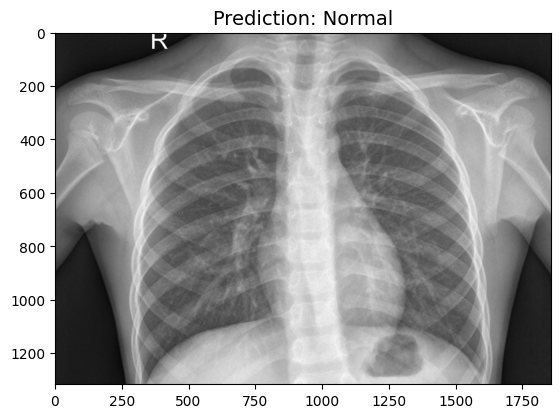

In [ ]:
import cv2
import matplotlib.pyplot as plt

def predict_pneumonia(model, img_path):
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE) # Read image in grayscale
    tempimg = img.copy()  # Keep copy
    img = cv2.resize(img, (224, 224)) # Resize to match model input size
    img = img / 255.0 # Normalize
    img = img.reshape(1, 224, 224, 1) # Reshape to match model input (batch_size, height, width, channels)
    prediction = model.predict(img)  # prediction

    prediction_label = "Pneumonia" if prediction.item() >= 0.5 else "Normal"
    print("Prediction:", prediction_label)
    plt.imshow(tempimg, cmap='gray')
    plt.title(f"Prediction: {prediction_label}", fontsize=14)
    plt.show()

#Example :
predict_pneumonia(model, "/content/IM-0001-0001.png")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
Prediction: Pneumonia


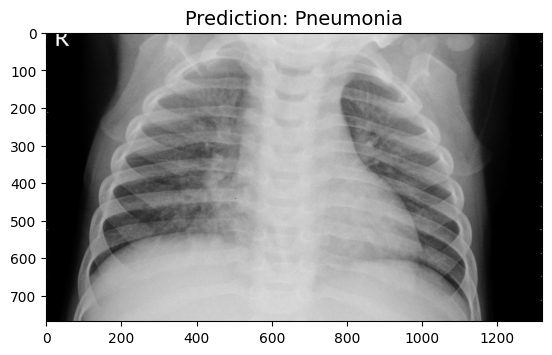

In [ ]:
predict_pneumonia(model, "/content/person65_virus_123.png")

In [ ]:
# Saving Model
model.save('/content/convxnet_model.h5')
print("Model saved in Colab storage!")

Model saved in Colab storage!


In [ ]:
# Save the model in Google Drive
model.save('/content/drive/MyDrive/convxnet_model.h5')
print("Model saved in Google Drive!")

Model saved in Google Drive!


**Using Custom CNN Architecture**

In [ ]:
# Custom CNN Model Definition
def CustomCNN(input_shape=(224, 224, 1)):
    inputs = tf.keras.layers.Input(shape=input_shape)

    # Block 1
    x = tf.keras.layers.Conv2D(16, (3,3), activation='relu')(inputs)
    x = tf.keras.layers.MaxPool2D(2,2)(x)

    # Block 2
    x = tf.keras.layers.Conv2D(32, (3,3), activation='relu')(x)
    x = tf.keras.layers.MaxPool2D(2,2)(x)

    # Block 3
    x = tf.keras.layers.Conv2D(64, (3,3), activation='relu')(x)
    x = tf.keras.layers.MaxPool2D(2,2)(x)

    # Block 4
    x = tf.keras.layers.Conv2D(128, (3,3), activation='relu')(x)
    x = tf.keras.layers.MaxPool2D(2,2)(x)

    # Block 5
    x = tf.keras.layers.Conv2D(128, (3,3), activation='relu')(x)
    x = tf.keras.layers.MaxPool2D(2,2)(x)

    # Fully Connected Layers
    x = tf.keras.layers.Flatten()(x)
    x = tf.keras.layers.Dense(256, activation='relu')(x)
    x = tf.keras.layers.Dense(512, activation='relu')(x)
    x = tf.keras.layers.Dense(1, activation='sigmoid')(x)

    # Define Model
    modell = tf.keras.models.Model(inputs, x)
    return modell

In [ ]:
modell = CustomCNN()

In [ ]:
modell.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)           │ (None, 224, 224, 1)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_8 (Conv2D)                    │ (None, 222, 222, 16)        │             160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 111, 111, 16)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_9 (Conv2D)                    │ (None, 109, 109, 32)        │           4,640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (None, 54, 54, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_10 (Conv2D)                   │ (None, 52, 52, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_6 (MaxPooling2D)       │ (None, 26, 26, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_11 (Conv2D)                   │ (None, 24, 24, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_7 (MaxPooling2D)       │ (None, 12, 12, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_12 (Conv2D)                   │ (None, 10, 10, 128)         │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_8 (MaxPooling2D)       │ (None, 5, 5, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 3200)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 256)                 │         819,456 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 512)                 │         131,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 1)                   │             513 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,196,289 (4.56 MB)

 Trainable params: 1,196,289 (4.56 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
modell.compile(optimizer= 'adam', loss= 'binary_crossentropy', metrics= ['accuracy'])

In [ ]:
historyy = modell.fit(train_generator, epochs = 50, validation_data = validation_generator)

Epoch 1/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 79s 447ms/step - accuracy: 0.7311 - loss: 0.5624 - val_accuracy: 0.7395 - val_loss: 0.5488
Epoch 2/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 64s 390ms/step - accuracy: 0.8345 - loss: 0.3441 - val_accuracy: 0.7878 - val_loss: 0.4535
Epoch 3/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 62s 382ms/step - accuracy: 0.8661 - loss: 0.3101 - val_accuracy: 0.7669 - val_loss: 0.5284
Epoch 4/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 64s 392ms/step - accuracy: 0.8722 - loss: 0.2888 - val_accuracy: 0.8392 - val_loss: 0.3938
Epoch 5/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 64s 395ms/step - accuracy: 0.8833 - loss: 0.2716 - val_accuracy: 0.8489 - val_loss: 0.3450
Epoch 6/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 64s 393ms/step - accuracy: 0.8893 - loss: 0.2512 - val_accuracy: 0.7605 - val_loss: 0.5831
Epoch 7/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 65s 397ms/step - accuracy: 0.8935 - loss: 0.2511 - val_accuracy: 0.7621 - val_loss: 0.4405
Epoch 8/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 83s 404ms/step - accuracy: 0.8982 - loss: 0

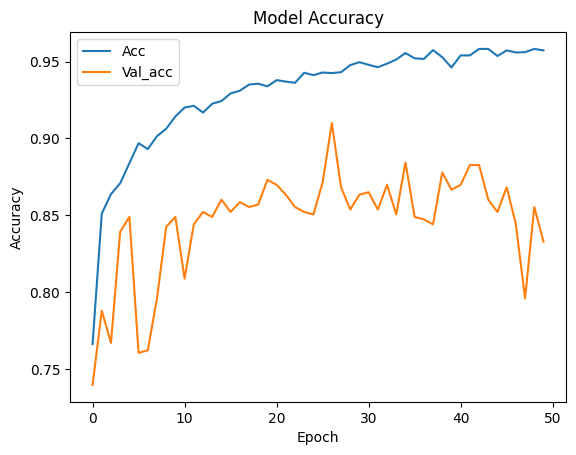

In [ ]:
#Visulaize the accuracy in each epoch
plt.plot(historyy.history['accuracy'],label='Acc')
plt.plot(historyy.history['val_accuracy'],label='Val_acc')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

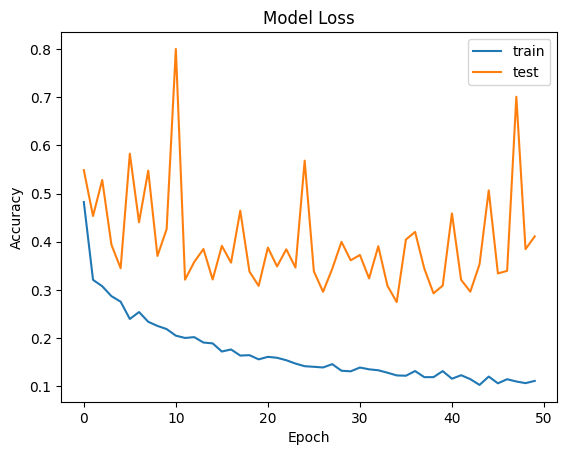

In [ ]:
#Visulaize the Loss in each epoch
import matplotlib.pyplot as plt
plt.plot(historyy.history['loss'],label='train')
plt.plot(historyy.history['val_loss'],label='test')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 812ms/step
Prediction: Normal


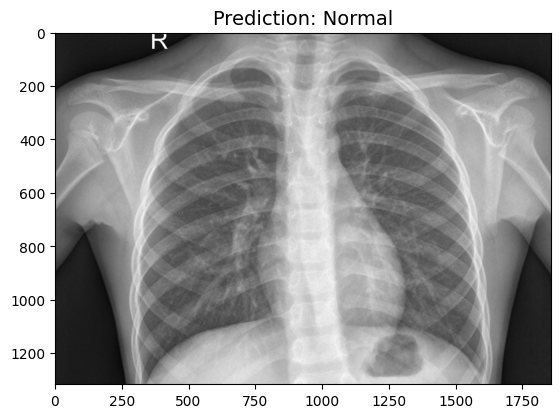

In [ ]:
import cv2
import matplotlib.pyplot as plt

def predict_pneumonia(model, img_path):
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE) # Read image in grayscale
    tempimg = img.copy()  # Keep copy
    img = cv2.resize(img, (224, 224)) # Resize to match model input size
    img = img / 255.0 # Normalize
    img = img.reshape(1, 224, 224, 1) # Reshape to match model input (batch_size, height, width, channels)
    prediction = modell.predict(img)  # prediction

    prediction_label = "Pneumonia" if prediction.item() >= 0.5 else "Normal"
    print("Prediction:", prediction_label)
    plt.imshow(tempimg, cmap='gray')
    plt.title(f"Prediction: {prediction_label}", fontsize=14)
    plt.show()

#Example :
predict_pneumonia(modell, "/content/IM-0001-0001.png")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
Prediction: Pneumonia


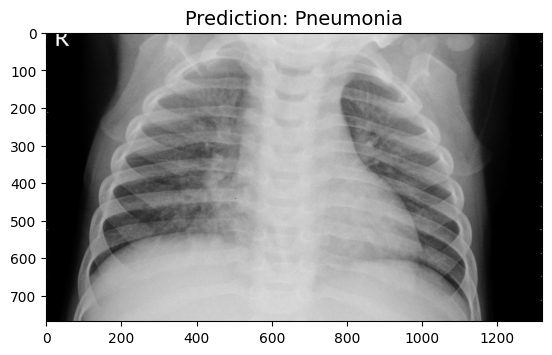

In [ ]:
predict_pneumonia(modell, "/content/person65_virus_123.png")

In [ ]:
modell.save('/content/customcnn_model.h5')
print("Model saved in Colab storage!")


Model saved in Colab storage!


In [ ]:
# Save the model in Google Drive
modell.save('/content/drive/MyDrive/convxnet_model.h5')
print("Model saved in Google Drive!")

Model saved in Google Drive!


In [ ]:
from tensorflow.keras.models import load_model
modell = load_model("/content/customcnn_model.h5")
print("Models loaded successfully!")


Models loaded successfully!


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Prediction: Pneumonia


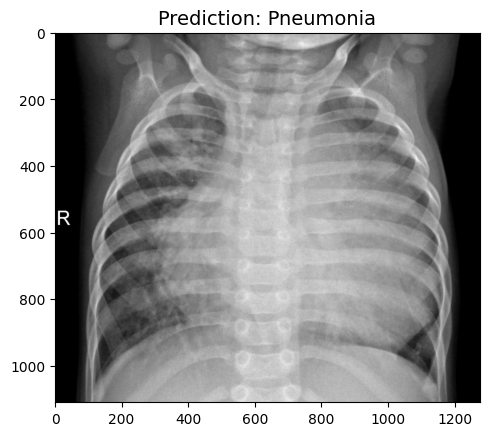

In [ ]:
import cv2
import matplotlib.pyplot as plt

def predict_pneumonia(model, img_path):
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE) # Read image in grayscale
    tempimg = img.copy()  # Keep copy
    img = cv2.resize(img, (224, 224)) # Resize to match model input size
    img = img / 255.0 # Normalize
    img = img.reshape(1, 224, 224, 1) # Reshape to match model input (batch_size, height, width, channels)
    prediction = modell.predict(img)  # prediction

    prediction_label = "Pneumonia" if prediction.item() >= 0.5 else "Normal"
    print("Prediction:", prediction_label)
    plt.imshow(tempimg, cmap='gray')
    plt.title(f"Prediction: {prediction_label}", fontsize=14)
    plt.show()

#Example :
predict_pneumonia(modell, "/content/person5_bacteria_15.png")


In [ ]:
!pip install -U segmentation-models-pytorch --quiet

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.8/58.8 kB 3.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.3/121.3 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 84.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 69.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 43.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 807.4 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 13.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
import cv2
import torch
import numpy as np
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
import segmentation_models_pytorch as smp


In [ ]:
# Check for GPU availability
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
# Load the Segmentation U-Net model
seg_model = smp.Unet("resnet34", encoder_weights="imagenet", in_channels=1, classes=1)
seg_model.to(device)
seg_model.eval()
print("Segmentation Model loaded successfully!")

Segmentation Model loaded successfully!


In [ ]:
# Preprocessing function
def preprocess_image(image_path, image_size=256):
    img = Image.open(image_path).convert("L")  # Convert to grayscale
    transform = transforms.Compose([
        transforms.Resize((image_size, image_size)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5], std=[0.5])
    ])
    return transform(img).unsqueeze(0).to(device), img


In [ ]:
# Pneumonia severity classification
def classify_pneumonia_severity(pneumonia_percentage):
    if pneumonia_percentage < 10:
        return "Mild Pneumonia"
    elif pneumonia_percentage < 40:
        return "Moderate Pneumonia"
    else:
        return "Severe Pneumonia"


In [ ]:
# Analyze severity using segmentation
def analyze_severity(image_path, threshold=0.6):
    input_tensor, original_img = preprocess_image(image_path)
    with torch.no_grad():
        output = seg_model(input_tensor)
        output_mask = torch.sigmoid(output).squeeze().cpu().numpy()

    binary_mask = (output_mask > threshold).astype(np.uint8)
    pneumonia_area = np.sum(binary_mask)
    total_area = np.prod(binary_mask.shape)
    pneumonia_percentage = (pneumonia_area / total_area) * 100
    severity = classify_pneumonia_severity(pneumonia_percentage)

    original_img_rgb = np.array(original_img.convert("RGB"))
    original_img_rgb = cv2.resize(original_img_rgb, (256, 256))
    red_overlay = original_img_rgb.copy()
    red_overlay[binary_mask == 1] = [255, 0, 0]
    blended = cv2.addWeighted(original_img_rgb, 0.7, red_overlay, 0.4, 0)

    return pneumonia_area, pneumonia_percentage, severity, output_mask, blended





In [ ]:
# CNN prediction function
def predict(model,image_path):
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    tempimg = image.copy()
    image = cv2.resize(image, (224, 224))
    image = image / 255.0
    image = image.reshape(1, 224, 224, 1)
    prediction = model.predict(image)
    label = "Pneumonia" if prediction.item() >= 0.5 else "Normal"
    return label, tempimg

In [ ]:
def predict_pneumonia_and_severity(model, image_path):
    label, _ = predict(model, image_path)
    print(f"\nPrediction Result: {label}")

    # Load and show original image
    original_img = Image.open(image_path).convert("L")
    original_img_resized = original_img.resize((256, 256))

    plt.figure(figsize=(15, 5))
    plt.subplot(1, 3, 1)
    plt.imshow(original_img_resized, cmap="gray")
    plt.title("Original Image")
    plt.axis("off")

    if label == "Pneumonia":
        area, percent, severity, output_mask, blended = analyze_severity(image_path)

        # Display mask
        plt.subplot(1, 3, 2)
        plt.imshow(output_mask, cmap="coolwarm")
        plt.title("Segmentation Mask")
        plt.axis("off")

        # Display blended image with overlay
        plt.subplot(1, 3, 3)
        plt.imshow(blended)
        plt.title(f"Highlighted Region\nSeverity: {severity}")
        plt.axis("off")
        plt.tight_layout()
        plt.show()

        # Final Clean Output
        print(f"Pneumonia Area (pixels): {area}")
        print(f"📏 Affected Percentage: {percent:.2f}%")
        print(f"⚠️ Severity Level: {severity}")

    else:
        plt.title("Normal")
        print("✅ Normal - No Pneumonia detected. No further analysis required.")
        plt.axis("off")
        plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step

Prediction Result: Pneumonia


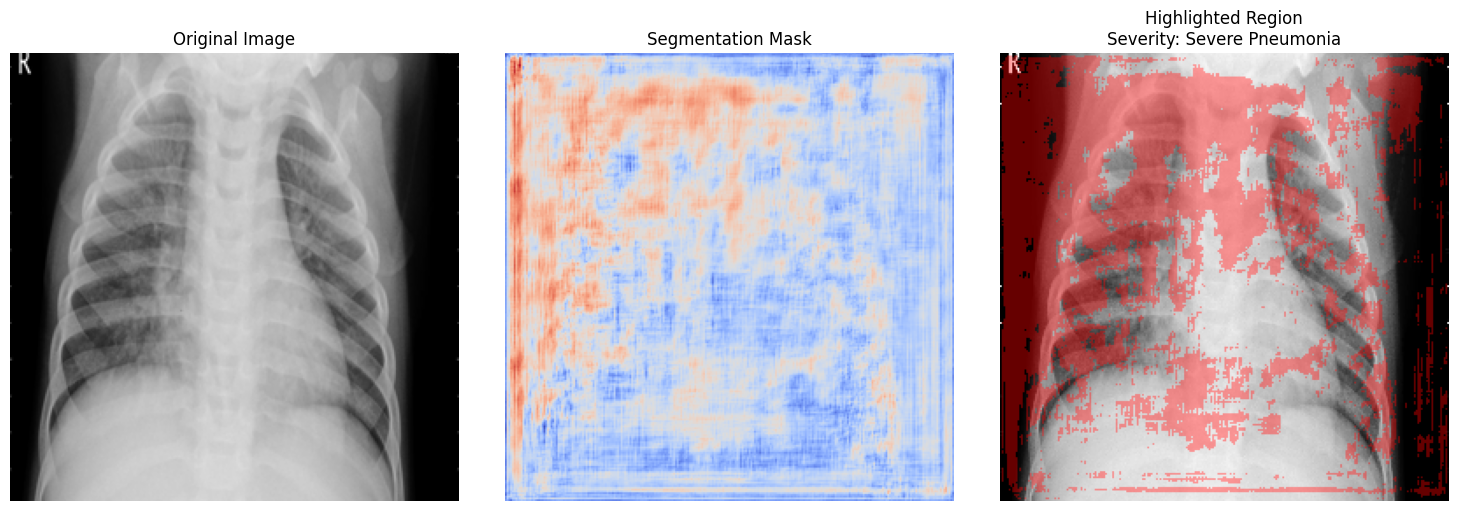

Pneumonia Area (pixels): 28816
📏 Affected Percentage: 43.97%
⚠️ Severity Level: Severe Pneumonia


In [ ]:
predict_pneumonia_and_severity(modell, "/content/person65_virus_123.png")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step

Prediction Result: Pneumonia


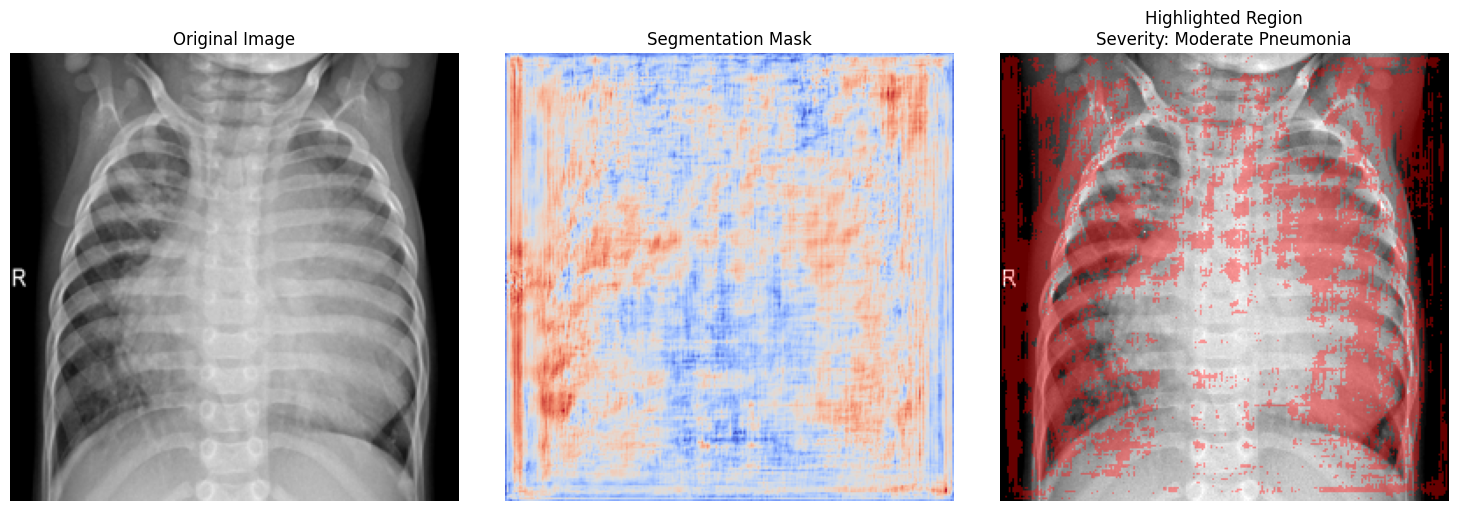

Pneumonia Area (pixels): 25531
📏 Affected Percentage: 38.96%
⚠️ Severity Level: Moderate Pneumonia


In [ ]:
predict_pneumonia_and_severity(modell, "/content/person5_bacteria_15.png")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step

Prediction Result: Normal
✅ Normal - No Pneumonia detected. No further analysis required.


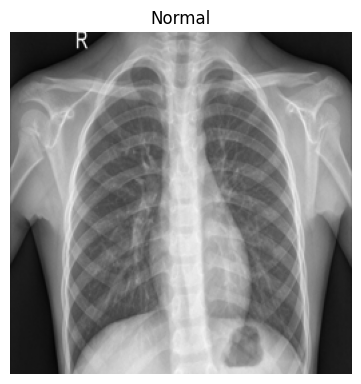

In [ ]:
predict_pneumonia_and_severity(modell, "/content/IM-0001-0001.png")

<ipython-input-17-f05afd7923fb>:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(class_counts.keys()), y=list(class_counts.values()), palette="Spectral")


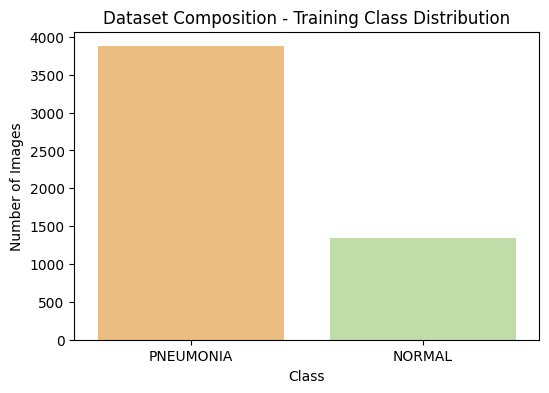

In [ ]:
import os
import matplotlib.pyplot as plt
import seaborn as sns

# Path to training dataset
train_path = "/content/chest_xray/train"

# Count number of images in each class
classes = os.listdir(train_path)
class_counts = {cls: len(os.listdir(os.path.join(train_path, cls))) for cls in classes}

# Bar graph
plt.figure(figsize=(6,4))
sns.barplot(x=list(class_counts.keys()), y=list(class_counts.values()), palette="Spectral")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.title("Dataset Composition - Training Class Distribution")
plt.show()


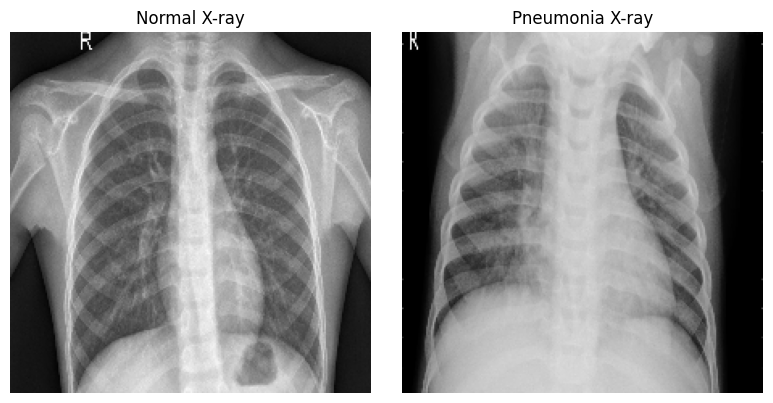

In [ ]:
import cv2
import matplotlib.pyplot as plt

# Manually specify the image file paths
normal_image_path = "/content/IM-0001-0001.png"  # Replace with actual path
pneumonia_image_path = "/content/person65_virus_123.png"  # Replace with actual path

# Load images in grayscale
normal_image = cv2.imread(normal_image_path, cv2.IMREAD_GRAYSCALE)
pneumonia_image = cv2.imread(pneumonia_image_path, cv2.IMREAD_GRAYSCALE)

# Resize both images to the same size (224x224)
normal_image = cv2.resize(normal_image, (224, 224))
pneumonia_image = cv2.resize(pneumonia_image, (224, 224))

# Display images
fig, axes = plt.subplots(1, 2, figsize=(8, 4))

axes[0].imshow(normal_image, cmap="gray")
axes[0].set_title("Normal X-ray")
axes[0].axis("off")

axes[1].imshow(pneumonia_image, cmap="gray")
axes[1].set_title("Pneumonia X-ray")
axes[1].axis("off")

#plt.suptitle("Fig. 2. Sample X-ray Images - Normal vs Pneumonia")
plt.tight_layout()
plt.show()


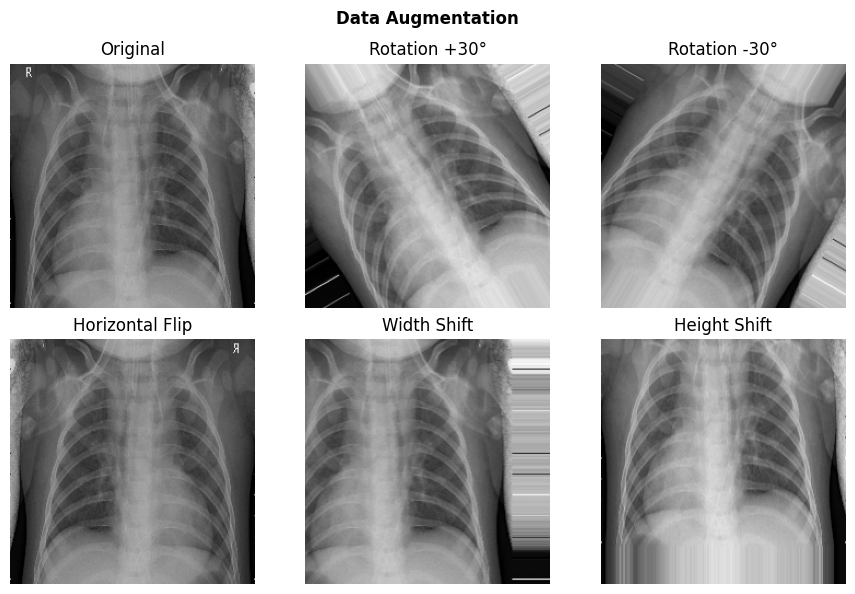

In [ ]:
Sdef display_augmented_images():
    fig, axes = plt.subplots(2, 3, figsize=(9, 6))  # Reduced figure size

    # Select a random Pneumonia image
    sample_image_path = random.choice(os.listdir(os.path.join(train_path, "PNEUMONIA")))
    sample_image = cv2.imread(os.path.join(train_path, "PNEUMONIA", sample_image_path), cv2.IMREAD_GRAYSCALE)

    # Resize and normalize image
    sample_image = cv2.resize(sample_image, (224, 224))
    sample_image = sample_image / 255.0
    sample_image = sample_image.reshape(1, 224, 224, 1)

    # Apply specific augmentations
    augmented_images = [
        train_datagen.apply_transform(sample_image[0], {'theta': 30}),  # Rotation +30°
        train_datagen.apply_transform(sample_image[0], {'theta': -30}), # Rotation -30°
        train_datagen.apply_transform(sample_image[0], {'flip_horizontal': True}),  # Horizontal Flip
        train_datagen.apply_transform(sample_image[0], {'tx': 0.15 * 224}),  # Width Shift +15%
        train_datagen.apply_transform(sample_image[0], {'ty': 0.15 * 224})   # Height Shift +15%
    ]

    # Titles for subplots
    titles = ["Original", "Rotation +30°", "Rotation -30°", "Horizontal Flip", "Width Shift", "Height Shift"]

    # Display images
    axes[0, 0].imshow(sample_image[0], cmap="gray")
    axes[0, 0].set_title(titles[0])
    axes[0, 0].axis("off")  # Remove axes

    for i, aug_img in enumerate(augmented_images):
        row, col = divmod(i+1, 3)  # Convert index to grid position
        axes[row, col].imshow(aug_img, cmap="gray")
        axes[row, col].set_title(titles[i+1])
        axes[row, col].axis("off")  # Remove axes

    # Figure title and layout
    plt.suptitle("Data Augmentation", fontsize=12, fontweight='bold')
    plt.tight_layout(pad=1)  # Adjust spacing
    plt.show()

# Call the function
display_augmented_images()


Found 5216 images belonging to 2 classes.
Found 624 images belonging to 2 classes.
Found 622 images belonging to 2 classes.


Model loaded successfully!


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


163/163 ━━━━━━━━━━━━━━━━━━━━ 32s 192ms/step


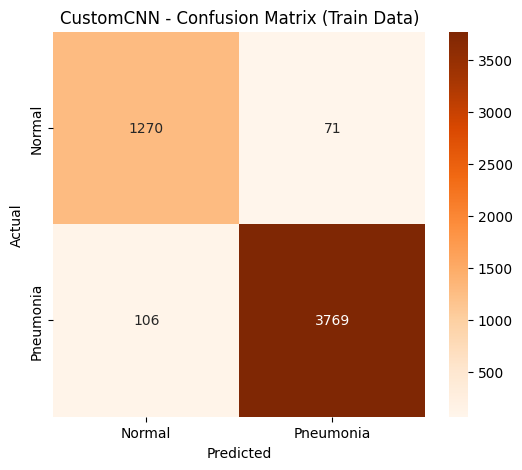


Classification Report (Train Data):
              precision    recall  f1-score   support

      Normal       0.92      0.95      0.93      1341
   Pneumonia       0.98      0.97      0.98      3875

    accuracy                           0.97      5216
   macro avg       0.95      0.96      0.96      5216
weighted avg       0.97      0.97      0.97      5216


Training Accuracy: 96.61%


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 141ms/step


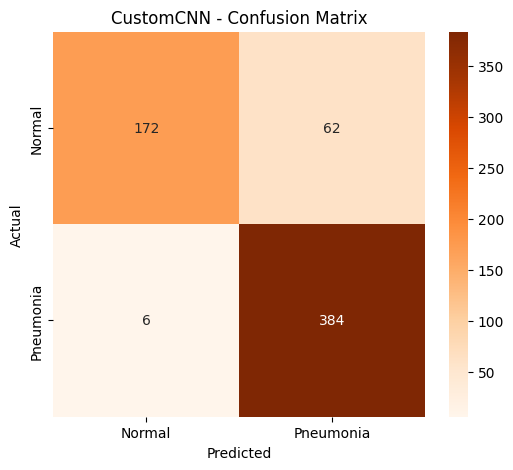


Classification Report (Test Data):
              precision    recall  f1-score   support

      Normal       0.97      0.74      0.83       234
   Pneumonia       0.86      0.98      0.92       390

    accuracy                           0.89       624
   macro avg       0.91      0.86      0.88       624
weighted avg       0.90      0.89      0.89       624


Test Accuracy: 89.10%


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 130ms/step


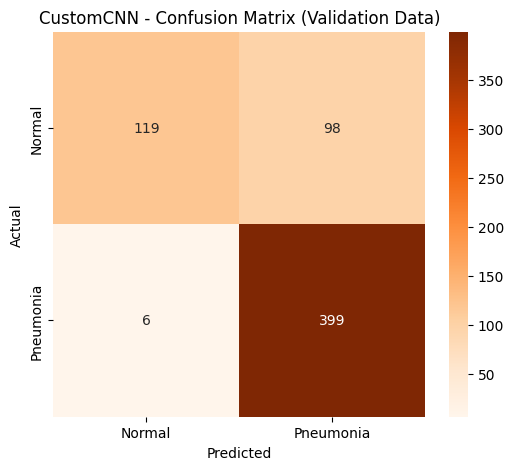


Classification Report (Validation Data):
              precision    recall  f1-score   support

      Normal       0.95      0.55      0.70       217
   Pneumonia       0.80      0.99      0.88       405

    accuracy                           0.83       622
   macro avg       0.88      0.77      0.79       622
weighted avg       0.85      0.83      0.82       622


Validation Accuracy: 83.28%


In [ ]:
from tensorflow.keras.models import load_model
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# --------------------- Data Generators ---------------------
train_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_images = "/content/chest_xray/train"
test_images = "/content/chest_xray/test"
validation_images = "/content/chest_xray/val"

train_generator = train_datagen.flow_from_directory(
    train_images,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    color_mode="grayscale",
    shuffle=False  # Important for correct label order
)

test_generator = test_datagen.flow_from_directory(
    test_images,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    color_mode="grayscale",
    shuffle=False
)

validation_generator = test_datagen.flow_from_directory(
    validation_images,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    color_mode="grayscale",
    shuffle=False
)

# --------------------- Load Model ---------------------
modell = load_model("/content/customcnn_model.h5")
print("Model loaded successfully!")

# --------------------- Predict & Evaluate on Training Data ---------------------
y_train_true = train_generator.classes
y_train_pred_prob = modell.predict(train_generator)
y_train_pred = (y_train_pred_prob > 0.5).astype(int).reshape(-1)

cm_train = confusion_matrix(y_train_true, y_train_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_train, annot=True, fmt='d', cmap='Oranges', xticklabels=['Normal', 'Pneumonia'], yticklabels=['Normal', 'Pneumonia'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('CustomCNN - Confusion Matrix (Train Data)')
plt.show()

print("\nClassification Report (Train Data):")
print(classification_report(y_train_true, y_train_pred, target_names=['Normal', 'Pneumonia']))
print(f"\nTraining Accuracy: {accuracy_score(y_train_true, y_train_pred) * 100:.2f}%")

# --------------------- Predict & Evaluate on Test Data ---------------------
y_test_true = test_generator.classes
y_test_pred_prob = modell.predict(test_generator)
y_test_pred = (y_test_pred_prob > 0.5).astype(int).reshape(-1)

cm_test = confusion_matrix(y_test_true, y_test_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Oranges', xticklabels=['Normal', 'Pneumonia'], yticklabels=['Normal', 'Pneumonia'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('CustomCNN - Confusion Matrix')
plt.show()

print("\nClassification Report (Test Data):")
print(classification_report(y_test_true, y_test_pred, target_names=['Normal', 'Pneumonia']))
print(f"\nTest Accuracy: {accuracy_score(y_test_true, y_test_pred) * 100:.2f}%")

# --------------------- Predict & Evaluate on Validation Data ---------------------
y_val_true = validation_generator.classes
y_val_pred_prob = modell.predict(validation_generator)
y_val_pred = (y_val_pred_prob > 0.5).astype(int).reshape(-1)

cm_val = confusion_matrix(y_val_true, y_val_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_val, annot=True, fmt='d', cmap='Oranges', xticklabels=['Normal', 'Pneumonia'], yticklabels=['Normal', 'Pneumonia'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('CustomCNN - Confusion Matrix (Validation Data)')
plt.show()

print("\nClassification Report (Validation Data):")
print(classification_report(y_val_true, y_val_pred, target_names=['Normal', 'Pneumonia']))
print(f"\nValidation Accuracy: {accuracy_score(y_val_true, y_val_pred) * 100:.2f}%")


Found 5216 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Model loaded successfully!

=== Evaluation on TRAIN Data ===
163/163 ━━━━━━━━━━━━━━━━━━━━ 37s 195ms/step


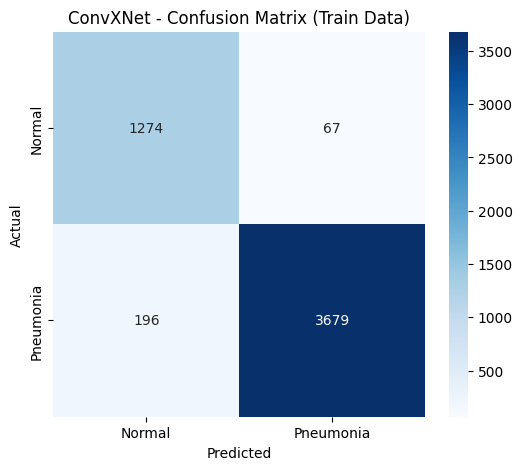

Classification Report (Train):
              precision    recall  f1-score   support

      Normal       0.87      0.95      0.91      1341
   Pneumonia       0.98      0.95      0.97      3875

    accuracy                           0.95      5216
   macro avg       0.92      0.95      0.94      5216
weighted avg       0.95      0.95      0.95      5216

Train Accuracy: 94.96%

=== Evaluation on TEST Data ===


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 297ms/step


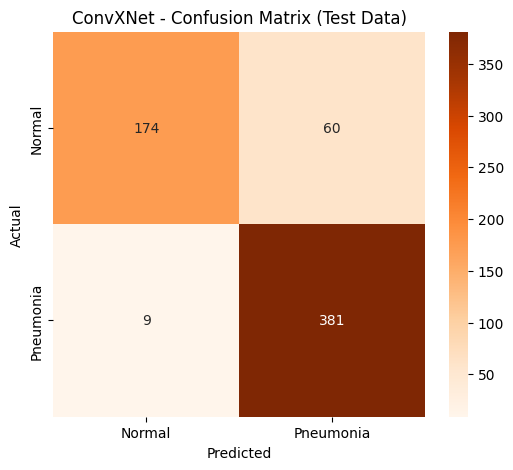

Classification Report (Test):
              precision    recall  f1-score   support

      Normal       0.95      0.74      0.83       234
   Pneumonia       0.86      0.98      0.92       390

    accuracy                           0.89       624
   macro avg       0.91      0.86      0.88       624
weighted avg       0.90      0.89      0.89       624

Test Accuracy: 88.94%


In [ ]:
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ----------------- ImageDataGenerators -----------------
datagen = ImageDataGenerator(rescale=1./255)

# Train Data Generator
train_images = "/content/chest_xray/train"
train_generator = datagen.flow_from_directory(
    train_images,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    color_mode='grayscale',
    shuffle=False  # Important for correct labels
)

# Test Data Generator
test_images = "/content/chest_xray/test"
test_generator = datagen.flow_from_directory(
    test_images,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    color_mode='grayscale',
    shuffle=False
)

# ----------------- Load ConvXNet Model -----------------
m = load_model("/content/convxnet_model.h5")
print("Model loaded successfully!")

# =====================================
# 🔹 Evaluation on TRAIN Data
# =====================================
print("\n=== Evaluation on TRAIN Data ===")
y_train_true = train_generator.classes
y_train_prob = m.predict(train_generator)
y_train_pred = (y_train_prob > 0.5).astype(int).reshape(-1)

# Confusion Matrix - Train
cm_train = confusion_matrix(y_train_true, y_train_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_train, annot=True, fmt='d', cmap='Blues', xticklabels=['Normal', 'Pneumonia'], yticklabels=['Normal', 'Pneumonia'])
plt.title("ConvXNet - Confusion Matrix (Train Data)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Classification Report - Train
print("Classification Report (Train):")
print(classification_report(y_train_true, y_train_pred, target_names=['Normal', 'Pneumonia']))
train_acc = accuracy_score(y_train_true, y_train_pred)
print(f"Train Accuracy: {train_acc * 100:.2f}%")

# =====================================
# 🔹 Evaluation on TEST Data
# =====================================
print("\n=== Evaluation on TEST Data ===")
y_test_true = test_generator.classes
y_test_prob = m.predict(test_generator)
y_test_pred = (y_test_prob > 0.5).astype(int).reshape(-1)

# Confusion Matrix - Test
cm_test = confusion_matrix(y_test_true, y_test_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Oranges', xticklabels=['Normal', 'Pneumonia'], yticklabels=['Normal', 'Pneumonia'])
plt.title("ConvXNet - Confusion Matrix (Test Data)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Classification Report - Test
print("Classification Report (Test):")
print(classification_report(y_test_true, y_test_pred, target_names=['Normal', 'Pneumonia']))
test_acc = accuracy_score(y_test_true, y_test_pred)
print(f"Test Accuracy: {test_acc * 100:.2f}%")


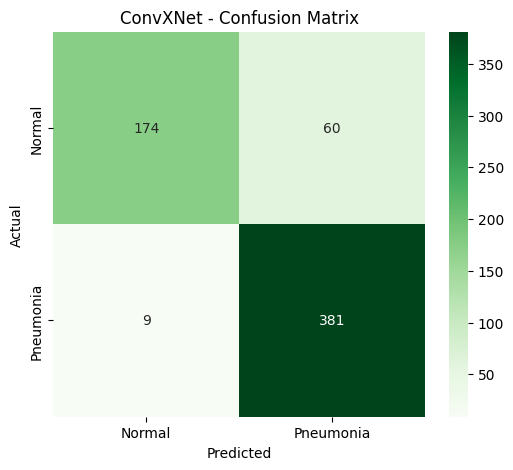

In [ ]:
# Confusion Matrix - Test
cm_test = confusion_matrix(y_test_true, y_test_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Greens', xticklabels=['Normal', 'Pneumonia'], yticklabels=['Normal', 'Pneumonia'])
plt.title("ConvXNet - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


Found 624 images belonging to 2 classes.


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Both models loaded successfully!
20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 170ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 145ms/step


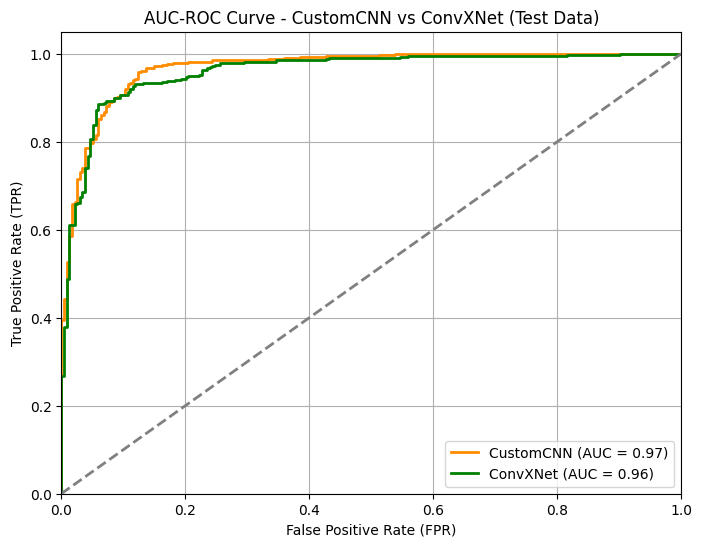

In [ ]:
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np

# ----------------- Test Data Generator -----------------
test_datagen = ImageDataGenerator(rescale=1./255)
test_images = "/content/chest_xray/test"
test_generator = test_datagen.flow_from_directory(
    test_images,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    color_mode='grayscale',
    shuffle=False
)

# ----------------- Load Models -----------------
customcnn = load_model("/content/customcnn_model.h5")
convxnet = load_model("/content/convxnet_model.h5")
print("Both models loaded successfully!")

# ----------------- Get True Labels -----------------
y_true = test_generator.classes

# ----------------- Get Probabilities -----------------
y_pred_customcnn = customcnn.predict(test_generator).ravel()
y_pred_convxnet = convxnet.predict(test_generator).ravel()

# ----------------- Calculate ROC curve and AUC -----------------
fpr_custom, tpr_custom, _ = roc_curve(y_true, y_pred_customcnn)
roc_auc_custom = auc(fpr_custom, tpr_custom)

fpr_convx, tpr_convx, _ = roc_curve(y_true, y_pred_convxnet)
roc_auc_convx = auc(fpr_convx, tpr_convx)

# ----------------- Plot ROC Curves -----------------
plt.figure(figsize=(8, 6))
plt.plot(fpr_custom, tpr_custom, color='darkorange', lw=2, label=f'CustomCNN (AUC = {roc_auc_custom:.2f})')
plt.plot(fpr_convx, tpr_convx, color='green', lw=2, label=f'ConvXNet (AUC = {roc_auc_convx:.2f})')
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')  # Diagonal Line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('AUC-ROC Curve - CustomCNN vs ConvXNet (Test Data)')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()


Found 624 images belonging to 2 classes.


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Both models loaded successfully!
20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 132ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 142ms/step


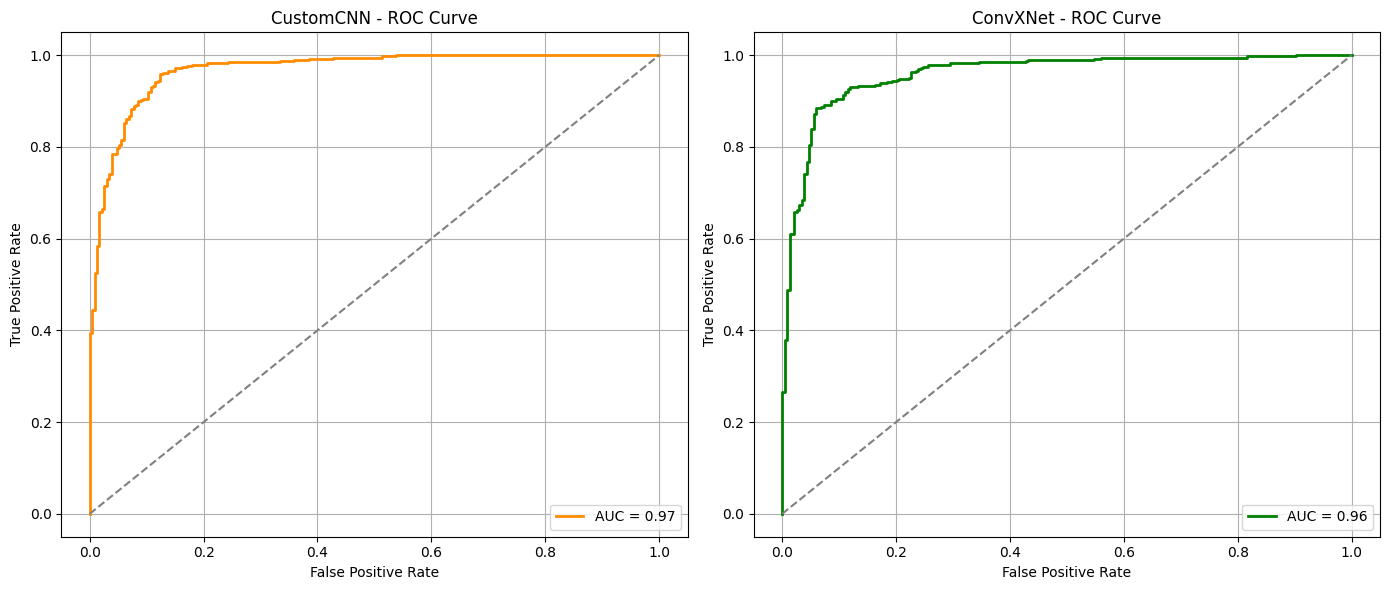

In [ ]:
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np

# ----------------- Test Data Generator -----------------
test_datagen = ImageDataGenerator(rescale=1./255)
test_images = "/content/chest_xray/test"
test_generator = test_datagen.flow_from_directory(
    test_images,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    color_mode='grayscale',
    shuffle=False
)

# ----------------- Load Models -----------------
customcnn = load_model("/content/customcnn_model.h5")
convxnet = load_model("/content/convxnet_model.h5")
print("Both models loaded successfully!")

# ----------------- Get True Labels -----------------
y_true = test_generator.classes

# ----------------- Get Prediction Probabilities -----------------
y_pred_customcnn = customcnn.predict(test_generator).ravel()
y_pred_convxnet = convxnet.predict(test_generator).ravel()

# ----------------- ROC and AUC -----------------
fpr_custom, tpr_custom, _ = roc_curve(y_true, y_pred_customcnn)
roc_auc_custom = auc(fpr_custom, tpr_custom)

fpr_convx, tpr_convx, _ = roc_curve(y_true, y_pred_convxnet)
roc_auc_convx = auc(fpr_convx, tpr_convx)

# ----------------- Plot Side-by-Side ROC Curves -----------------
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# CustomCNN ROC
axes[0].plot(fpr_custom, tpr_custom, color='darkorange', lw=2, label=f'AUC = {roc_auc_custom:.2f}')
axes[0].plot([0, 1], [0, 1], color='gray', linestyle='--')
axes[0].set_title('CustomCNN - ROC Curve')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend(loc='lower right')
axes[0].grid(True)

# ConvXNet ROC
axes[1].plot(fpr_convx, tpr_convx, color='green', lw=2, label=f'AUC = {roc_auc_convx:.2f}')
axes[1].plot([0, 1], [0, 1], color='gray', linestyle='--')
axes[1].set_title('ConvXNet - ROC Curve')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend(loc='lower right')
axes[1].grid(True)

plt.tight_layout()
plt.show()
